In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r"..\Datasets\student_marks.csv")
df

,number_courses,time_study,Marks
0,3,4.508,19.202
1,4,0.096,7.734
2,4,3.133,13.811
3,6,7.909,53.018
4,8,7.811,55.299
...,...,...,...
95,6,3.561,19.128
96,3,0.301,5.609
97,4,7.163,41.444
98,7,0.309,12.027


In [3]:
df.columns

Index(['number_courses', 'time_study', 'Marks'], dtype='object')

In [4]:
df.dtypes

number_courses      int64
time_study        float64
Marks             float64
dtype: object

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   number_courses  100 non-null    int64  
 1   time_study      100 non-null    float64
 2   Marks           100 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


In [6]:
df.isnull().sum()

number_courses    0
time_study        0
Marks             0
dtype: int64

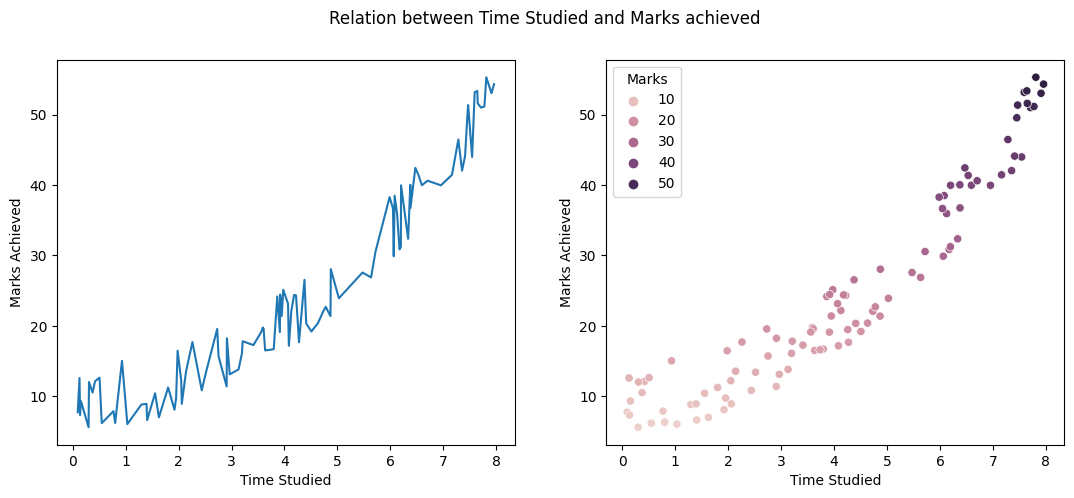

In [7]:
plt.figure(figsize = (13,5))
plt.suptitle('Relation between Time Studied and Marks achieved')
plt.subplot(121)
sns.lineplot(data = df, x = 'time_study', y = 'Marks')
plt.xlabel('Time Studied')
plt.ylabel('Marks Achieved')
plt.subplot(122)
sns.scatterplot(data = df, x = 'time_study', y = 'Marks', hue = df.Marks)
plt.xlabel('Time Studied')
plt.ylabel('Marks Achieved')
plt.show()

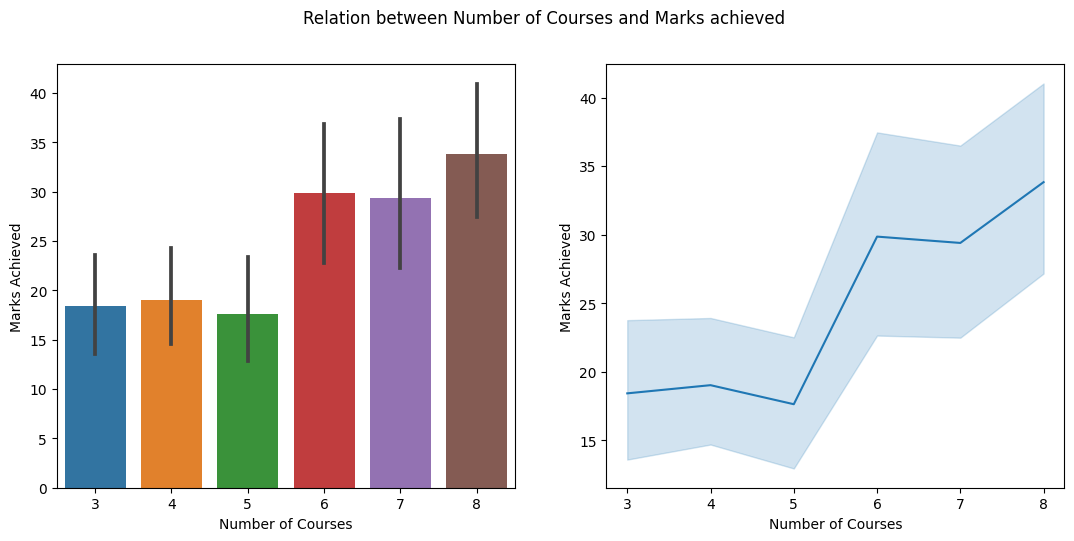

In [8]:
plt.figure(figsize = (13,5.5))
plt.suptitle('Relation between Number of Courses and Marks achieved')
plt.subplot(121)
sns.barplot(data = df, x = 'number_courses', y = 'Marks')
plt.xlabel('Number of Courses')
plt.ylabel('Marks Achieved')
plt.subplot(122)
sns.lineplot(data = df, x = 'number_courses', y = 'Marks')
plt.xlabel('Number of Courses')
plt.ylabel('Marks Achieved')
plt.show()

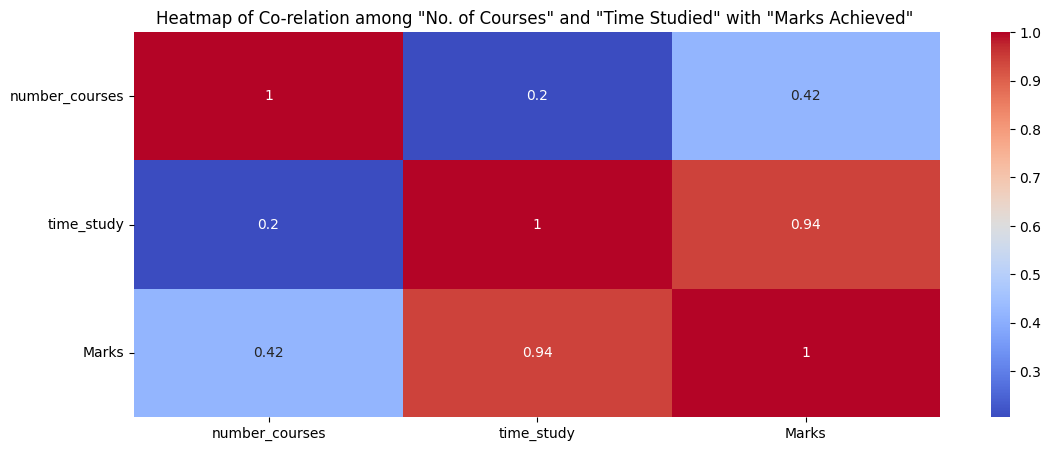

In [9]:
plt.figure(figsize = (13,5))
sns.heatmap(df.corr(), annot = True, cmap = 'coolwarm')
plt.yticks(rotation = 0)
plt.title('Heatmap of Co-relation among "No. of Courses" and "Time Studied" with "Marks Achieved" ')
plt.show()

In [10]:
ip = df.drop(['Marks'], axis = 1)
ip

,number_courses,time_study
0,3,4.508
1,4,0.096
2,4,3.133
3,6,7.909
4,8,7.811
...,...,...
95,6,3.561
96,3,0.301
97,4,7.163
98,7,0.309


In [11]:
op = df['Marks']
op

0     19.202
1      7.734
2     13.811
3     53.018
4     55.299
       ...  
95    19.128
96     5.609
97    41.444
98    12.027
99    32.357
Name: Marks, Length: 100, dtype: float64

In [12]:
x_train, x_test, y_train, y_test = train_test_split(ip, op, train_size = 0.7)

In [13]:
df.shape, x_train.shape, x_test.shape

((100, 3), (70, 2), (30, 2))

In [14]:
sc = StandardScaler()
sc

StandardScaler()

In [15]:
x_train = sc.fit_transform(x_train)
x_test = sc.fit_transform(x_test)

In [16]:
lr = LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

In [17]:
ycap = lr.predict(x_test)
ycap

array([18.23958633, 20.21057442, 26.21592478, -0.08369292, 48.12187175,
       -0.61128837, 19.08573192, 21.50343238, 23.09147244, 20.39625168,
        7.87525526, 40.66706047, 47.31603194, 17.4626398 , 13.5850615 ,
       26.01321928, 49.97665317, 15.77034861, 18.95847478, 32.38358436,
       33.57789744, 10.87779468, 27.69980422, 29.39281947, 41.91916011,
       -0.8663457 , 31.351671  ,  6.66364242, 41.53113938, 49.26365199])

In [18]:
pdf = pd.DataFrame({'y':list(y_test),
                    'prediction':ycap})
pdf

,y,prediction
0,15.725,18.239586
1,17.264,20.210574
2,22.184,26.215925
3,6.185,-0.083693
4,53.018,48.121872
5,7.336,-0.611288
6,17.705,19.085732
7,17.672,21.503432
8,19.771,23.091472
9,17.171,20.396252


In [19]:
mse = mean_squared_error(y_test, ycap)
print("Mean Squared Error: ", mse)

Mean Squared Error:  14.175302981949212


In [20]:
r2 = r2_score(y_test, ycap)
print("R2 Score:", r2)
print("Accuracy:", r2*100)

R2 Score: 0.9313351135771041
Accuracy: 93.1335113577104


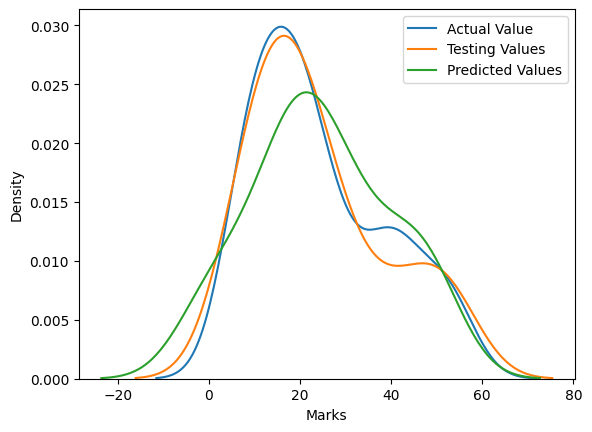

In [21]:
sns.kdeplot(df['Marks'], label = "Actual Value")
sns.kdeplot(y_test, label = "Testing Values")
sns.kdeplot(ycap, label = "Predicted Values")
plt.legend()
plt.show()